In [9]:
from google.colab import drive

# This command will open an authentication prompt.
# Click the link, sign in, copy the authorization code, and paste it into the box.
drive.mount('/content/drive')

print("Google Drive mounted successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.


In [11]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
import numpy as np

# --- 1. Define Constants ---
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 5 # Small batch size for the small dataset (5 * 8 images = 40 total)
N_CLASSES = 5

# !!! CRITICAL: CONFIRM THIS PATH MATCHES YOUR GOOGLE DRIVE LOCATION !!!
DATA_DIR = '/content/drive/MyDrive/logos_dataset'
# !!! --------------------------------------------------------------- !!!




In [12]:
# --- 2. Image Augmentation and Data Loaders ---

# Training Generator: Includes Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,                 # Normalize pixel values
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Testing Generator: Only Rescaling
test_datagen = ImageDataGenerator(rescale=1./255)

# Load data from directories
# This will show the exact counts (e.g., 40 images belonging to 5 classes)
train_generator = train_datagen.flow_from_directory(
    f'{DATA_DIR}/training_set',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    f'{DATA_DIR}/testing_set',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 27 images belonging to 5 classes.
Found 7 images belonging to 5 classes.


In [13]:
# --- 3. Load VGG16 Base Model (Feature Extractor) ---
# Weights='imagenet' loads the model pre-trained on millions of images
conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the convolutional base so only the new layers are trained
conv_base.trainable = False

In [14]:
# --- 4. Build the New Classification Model ---
model = Sequential([
    conv_base,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(N_CLASSES, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,757 (80.64 MB)

 Trainable params: 6,424,069 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [15]:
# --- 5. Compile the Model ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
# --- 6. Train the Model ---
# Epochs are set higher (50) to compensate for the tiny dataset
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=50,
    validation_data=test_generator,
    validation_steps=test_generator.samples // BATCH_SIZE
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - accuracy: 0.2558 - loss: 2.1030 - val_accuracy: 0.2000 - val_loss: 1.6234
Epoch 2/50
1/5 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.2000 - loss: 1.9116

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.2000 - loss: 1.9116 - val_accuracy: 0.0000e+00 - val_loss: 1.9131
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 28s 4s/step - accuracy: 0.6514 - loss: 1.2169 - val_accuracy: 0.4000 - val_loss: 1.1960
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.6000 - loss: 1.3727 - val_accuracy: 0.4000 - val_loss: 1.0588
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - accuracy: 0.6336 - loss: 0.9700 - val_accuracy: 1.0000 - val_loss: 0.4805
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 671ms/step - accuracy: 0.4000 - loss: 1.1465 - val_accuracy: 0.8000 - val_loss: 0.4947
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.7266 - loss: 0.8852 - val_accuracy: 1.0000 - val_loss: 0.4542
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 669ms/step - accuracy: 0.6000 - loss: 0.7756 - val_accuracy: 1.0000 - val_loss: 0.3599
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - accuracy: 0.8747 - loss: 0.3577 - val_accuracy: 1.0000 - val_loss: 0.2653
Epoch 10/50
5

In [17]:
# --- 7. Test on the Testing Part (Evaluation) ---
print("\n--- Model Evaluation ---")

loss, accuracy = model.evaluate(
    test_generator,
    steps=test_generator.samples // BATCH_SIZE
)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")


--- Model Evaluation ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 1.0000 - loss: 0.0138

Test Loss: 0.0138
Test Accuracy: 100.00%


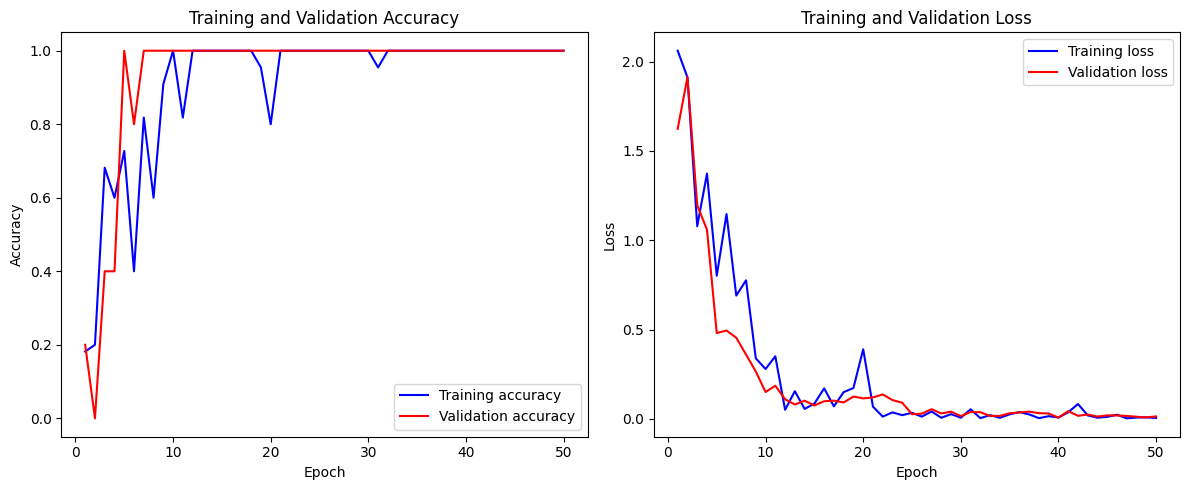

In [19]:
import matplotlib.pyplot as plt

# Retrieve the metrics from the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

# --- Plot Training and Validation Accuracy ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# --- Plot Training and Validation Loss ---
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
